In [121]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression


from sklearn.metrics import accuracy_score, roc_curve, auc, roc_auc_score

In [2]:
# url = https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv
# !wget url

In [3]:
df = pd.read_csv('../data/course_lead_scoring_2026.csv')

In [47]:
df.columns

Index(['lead_source', 'industry', 'employment_status', 'location',
       'annual_income', 'number_of_courses_viewed', 'interaction_count',
       'lead_score', 'converted'],
      dtype='str')

In [74]:
categorical = list(df.dtypes[df.dtypes == 'str'].index)
df[categorical] = df[categorical].fillna('NA')

numerical = list(df.dtypes[df.dtypes != 'str'].index)
numerical.remove('converted')
df[numerical] = df[numerical].fillna(0)

# Desired target 'converted'. Has the customer converted or not
# df.isnull().sum()

In [40]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

# reset the index
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# get target
y_train = df_train['converted'].values
y_val = df_val['converted'].values
y_val = df_test['converted'].values


# drop target
del df_train['converted']
del df_val['converted']
del df_test['converted']

In [64]:
def train(df, y_train, c=1.0):
    x_dict = df_train[numerical + categorical].to_dict(orient="records")

    dv = DictVectorizer(sparse=False)
    x_train = dv.fit_transform(x_dict)

    model = LogisticRegression(C=c, max_iter=10000)
    model.fit(x_train, y_train)

    return dv, model

In [72]:
def predict(df, dv, model):
    dicts = df[numerical + categorical].to_dict(orient="records")
    
    x_pred = dv.transform(dicts)
    y_pred = model.predict_proba(x_pred)[:,1]

    return y_pred

In [76]:
dict_vectorizer, model = train(df_train, y_train)

y_pred = predict(df_val, dict_vectorizer, model)


0.00 0.568
0.05 0.566
0.10 0.568
0.15 0.561
0.20 0.558
0.25 0.550
0.30 0.544
0.35 0.531
0.40 0.531
0.45 0.534
0.50 0.527
0.55 0.522
0.60 0.507
0.65 0.502
0.70 0.498
0.75 0.489
0.80 0.469
0.85 0.466
0.90 0.457
0.95 0.438
1.00 0.432


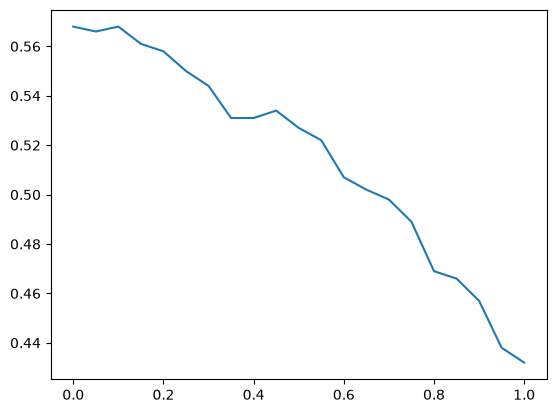

In [96]:
thresholds = np.linspace(0, 1, 21)

scores = []

for t in thresholds:
    score = accuracy_score(y_val, y_pred >= t)
    print(f"{t:.2f} {score:.3f}")
    scores.append(score)

plt.plot(thresholds, scores)

In [125]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

t = 0.5
predict_positive = (y_pred >= t)
predict_negative = (y_pred < t)

tp = (predict_positive & actual_positive).sum()
tn = (predict_negative & actual_negative).sum()

fp = (predict_positive & actual_negative).sum()
fn = (predict_negative & actual_positive).sum()

In [105]:
from IPython.display import display


confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])
display(confusion_matrix)

# precision = how many true positives did I predict correctly
precision = tp / (tp + fp)
# recall = how many true positives did I catch i.e, trues_caught + trues_no_caught(false negative)
recall = tp / (tp + fn)

display(precision, recall)

array([[158, 274],
       [199, 369]])

np.float64(0.5738724727838258)

np.float64(0.6496478873239436)

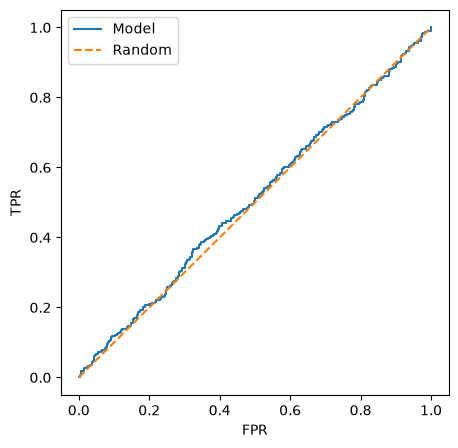

In [120]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)

plt.figure(figsize=(5, 5))

plt.plot(fpr, tpr, label='Model')
plt.plot([0, 1], [0, 1], label='Random', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

In [149]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
auc(fpr, tpr)

0.5080733242044861

In [150]:
roc_auc_score(y_val, y_pred)

0.5080733242044861

In [168]:
'''
Question 1: ROC AUC feature importance
'''

for num in numerical:
    y_score = df_train[num]
    score = roc_auc_score(y_true=y_train, y_score=y_score)
    if score < 0.5:
        score = roc_auc_score(y_true=y_train, y_score=-y_score)
    print(f"{num}: {score}")

# annual_income: 0.6081977776250831
# number_of_courses_viewed: 0.7229894623989618
# interaction_count: 0.7649203047563227
# lead_score: 0.7882254810906102

# Answer: lead_score

annual_income: 0.6081977776250831
number_of_courses_viewed: 0.7229894623989618
interaction_count: 0.7649203047563227
lead_score: 0.7882254810906102


In [166]:
# precision -> "Among transactions I flag as fraud, how many are actually fraudulent?"
# recall -> "Of all fraudulent transactions, how many did I catch?"

# roc -> returns fpr (false positive rate), tpr(true positive rate),/
#     and several thresholds(e.g t = 0.5, but it gives a huge array take for instance np.linspace(0,1,101)
# auc -> area under curve. It requires fpr and tpr as inputs.(
#     0.0: terrible model
#     0.5: random-guessing model
#     0.7: decent model
#     0.9: good model
#     1.0: perfect model
# )
# roc_auc_score -> calculates auc score i.e it first calculates roc(returns fpr, tpr, threshholds) then auc(returns auc score)./
#     It is inteprated as: The probability that your model gives the customer who will cancel a higher score than the customer who won't.

In [173]:
'''
Question 2: Training the model

What's the AUC of this model on the validation dataset? (round to 3 digits)
'''
X_dicts = df_train[numerical + categorical].to_dict(orient="records")
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(X_dicts)

model_2 = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model_2.fit(X_train, y_train)


X_val_dicts = df_val[numerical + categorical].to_dict(orient="records")
X_val = dv.transform(X_val_dicts)
y_val_pred = model_2.predict_proba(X_val)[:,1]

score = roc_auc_score(y_true=y_val, y_score=y_val_pred)
score

# 0.508317846896192

0.508317846896192

In [175]:
'''
Question 3: Precision and Recall
'''

thresholds = np.linspace(0,1,101)
# thresholds